# ML-10 — Content Action Playbook

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/flyrank-bih/flyrank-ml-internship-starter/blob/main/work/notebooks/w07_action_playbook.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

In [1]:
import os, getpass
import duckdb
import pandas as pd
import numpy as np
import json
from sklearn.model_selection import GroupShuffleSplit
from sklearn.linear_model import LogisticRegression

HF_TOKEN = os.environ.get('HF_TOKEN')
if not HF_TOKEN:
    try:
        from google.colab import userdata
        HF_TOKEN = userdata.get('HF_TOKEN')
    except Exception:
        pass
HF_TOKEN = HF_TOKEN or getpass.getpass('Paste your Hugging Face READ token (hf_...): ')

con = duckdb.connect()
con.execute(f"CREATE OR REPLACE SECRET hf (TYPE huggingface, TOKEN '{HF_TOKEN}')")

REL = 'hf://datasets/FlyRank/internship-warehouse'
FACT = f"read_parquet('{REL}/fact_content_daily_performance/**/*.parquet')"
DIM_CONTENT = f"read_parquet('{REL}/dim_content.parquet')"
QUERY90 = f"read_parquet('{REL}/fact_content_query_90d.parquet')"
CUTOFF, QUERY_START, MONTH_END = "2026-03-01", "2026-02-01", "2026-03-31"

feat_frame_full = con.sql(f"""
    WITH windowed AS (
        SELECT client_hash_id, content_hash_id,
            SUM(CASE WHEN report_date > DATE '{CUTOFF}' THEN gsc_impressions ELSE 0 END) AS imp_last30,
            SUM(CASE WHEN report_date <= DATE '{CUTOFF}' THEN gsc_impressions ELSE 0 END) AS imp_prev30,
            SUM(CASE WHEN report_date <= DATE '{CUTOFF}' THEN gsc_clicks ELSE 0 END) AS clk_prev30,
            AVG(CASE WHEN report_date <= DATE '{CUTOFF}' THEN gsc_avg_position END) AS pos_prev30
        FROM {FACT}
        WHERE report_date BETWEEN '{QUERY_START}' AND '{MONTH_END}'
        GROUP BY 1, 2 HAVING imp_prev30 >= 50
    ) SELECT * FROM windowed
""").df()

qsignals = con.sql(f"SELECT content_hash_id, ANY_VALUE(content_visible_query_count) AS visible_queries FROM {QUERY90} GROUP BY content_hash_id").df()
content_age = con.sql(f"SELECT content_hash_id, DATE_DIFF('day', content_created_date, DATE '{MONTH_END}') AS content_age_days FROM {DIM_CONTENT}").df()

feat_frame_full = feat_frame_full.merge(qsignals, on='content_hash_id', how='left').merge(content_age, on='content_hash_id', how='left')
feat_frame_full['is_declining'] = (feat_frame_full['imp_last30'] < 0.8 * feat_frame_full['imp_prev30']).astype(int)

cols = ['imp_prev30','clk_prev30','pos_prev30','visible_queries','content_age_days']
model_df = feat_frame_full.dropna(subset=cols).reset_index(drop=True)

X, y, groups = model_df[cols], model_df['is_declining'], model_df['client_hash_id']
gss = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups))
X_train, y_train = X.iloc[train_idx], y.iloc[train_idx]

logreg = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42).fit(X_train, y_train)
print("Pipeline rebuilt — ready for the playbook.")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Pipeline rebuilt — ready for the playbook.


## 1. Ranked actions + reason codes

*The queue: what to do first, and why, in words a human trusts.*

In [2]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.
model_df['risk_score'] = logreg.predict_proba(X)[:, 1]

med_age = model_df['content_age_days'].median()
med_vis = model_df['visible_queries'].median()
q75_imp = model_df['imp_prev30'].quantile(0.75)

def reason_code(row):
    if row['content_age_days'] > med_age and row['visible_queries'] < med_vis:
        return 'aging_narrow_visibility'
    elif row['imp_prev30'] > q75_imp:
        return 'high_traffic_volatility'
    else:
        return 'general_decline_risk'

model_df['reason_code'] = model_df.apply(reason_code, axis=1)
model_df['action'] = 'review_for_refresh_or_consolidation'

ranked_queue = model_df.sort_values('risk_score', ascending=False).reset_index(drop=True)
ranked_queue[['client_hash_id','content_hash_id','risk_score','reason_code','action']].head(20)

,client_hash_id,content_hash_id,risk_score,reason_code,action
0,client_73cda7b4e4f265ea,content_9c057b66c30a3abb,1.000000,aging_narrow_visibility,review_for_refresh_or_consolidation
1,client_73cda7b4e4f265ea,content_8e1334d6356668e3,1.000000,high_traffic_volatility,review_for_refresh_or_consolidation
2,client_73cda7b4e4f265ea,content_fec55986a1868d62,1.000000,high_traffic_volatility,review_for_refresh_or_consolidation
3,client_73cda7b4e4f265ea,content_c9f840183215651b,1.000000,high_traffic_volatility,review_for_refresh_or_consolidation
4,client_23a62021009f63c4,content_2ac8c7995de53cd1,1.000000,high_traffic_volatility,review_for_refresh_or_consolidation
5,client_23a62021009f63c4,content_44f34c0a90047651,1.000000,high_traffic_volatility,review_for_refresh_or_consolidation
6,client_73cda7b4e4f265ea,content_252aa5480bb1f8d7,0.999999,high_traffic_volatility,review_for_refresh_or_consolidation
7,client_62f4a7e64f5e0096,content_7c6373141eae744a,0.999998,high_traffic_volatility,review_for_refresh_or_consolidation
8,client_73cda7b4e4f265ea,content_db122b8ba22641b8,0.999997,high_traffic_volatility,review_for_refresh_or_consolidation
9,client_62f4a7e64f5e0096,content_3e07fb36c28b980e,0.999994,high_traffic_volatility,review_for_refresh_or_consolidation


Each page gets a risk score from the validated model (Precision@50 = 0.380 on a client-grouped holdout, ~2.1x the 18.2% base rate) and one of three reason codes derived from the model's top features: aging_narrow_visibility (older content with few distinct ranking queries — the model's two strongest signals), high_traffic_volatility (large absolute impression swings on high-traffic pages), or general_decline_risk for everything else. The action is the same for every row — review_for_refresh_or_consolidation — because this model flags candidates for a person to look at, it doesn't prescribe a specific fix.

## 2. Intended use and limits

*Who uses this, for what — and where it stops being valid.*

Intended use: a weekly prioritization aid for a content team deciding which pages to review first, within the same lane and data scope this was built and validated on (March 2026 snapshot, Lane 2 clients with ≥50 prior-window impressions). Limits: this is observational, cross-sectional data — it does not show that refreshing a flagged page will cause recovery, only that similar pages were observed declining more often. It has only been validated on one month; performance on a different month, season, or newly onboarded client is unknown. The label itself is a proxy (30-day impression drop ≥20%), not a ground-truth outcome.

## 3. Human review + the no-go list

*What a person must check before acting. What should never be automated.*

Before acting on any flagged page, a reviewer should: confirm the page's search intent still matches its content, check whether a recent manual change already addressed the issue, and sanity-check that the decline isn't explained by something outside content quality (seasonality, a tracked outage, a URL change). No-go list — this should never be automated: auto-publishing content changes, auto-deprioritizing or removing pages from a site, reallocating budget or traffic based on score alone without sign-off, or applying this queue to a client type or time period it wasn't validated on.

## 4. Monitoring / retrain triggers

*What would tell you the recommendations went stale?*

Retrain or re-validate if: the base rate of declining pages drifts meaningfully from 18.2% (signals the portfolio composition changed), the feature importance ranking shifts significantly from the current order (visible_queries, content_age_days, imp_prev30 dominant), a new client segment is added that wasn't in the training population, or three consecutive months pass without a recheck against fresh data — this model has only been tested on one static month and shouldn't be trusted indefinitely on that basis alone.

## 5. Exports for the paper

*Write the queue (and any figures you want to reuse) to work/outputs/ — your paper builds on these files.*

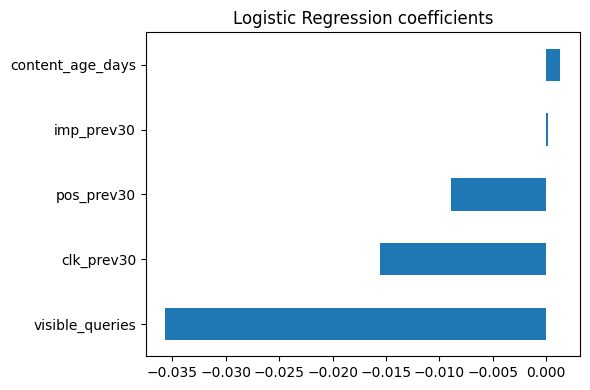

Exported: content_action_queue.csv, w07_metrics.json, feature_importance.png


In [3]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.
os.makedirs("work/outputs", exist_ok=True)
os.makedirs("work/figures", exist_ok=True)

ranked_queue[['client_hash_id','content_hash_id','risk_score','reason_code','action']].to_csv(
    "work/outputs/content_action_queue.csv", index=False)

metrics = {
    "precision_at_50_grouped": 0.380,
    "precision_at_50_random_split": 0.640,
    "base_rate": round(float(y.mean()), 4),
    "week4_baseline_precision_at_50": 0.0,
    "feature_importance_rank": ["visible_queries","content_age_days","imp_prev30","pos_prev30","clk_prev30"],
    "validated_window": "2026-03 (Feb+Mar features)",
    "split_design": "GroupShuffleSplit by client_hash_id, test_size=0.25"
}
with open("work/outputs/w07_metrics.json", "w") as f:
    json.dump(metrics, f, indent=2)

import matplotlib.pyplot as plt
importances = pd.Series(logreg.coef_[0], index=cols).sort_values()
plt.figure(figsize=(6,4))
importances.plot(kind='barh')
plt.title("Logistic Regression coefficients")
plt.tight_layout()
plt.savefig("work/figures/feature_importance.png")
plt.show()

print("Exported: content_action_queue.csv, w07_metrics.json, feature_importance.png")

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.